# (4) Emulated quantities vs the Frontier-E simulation

**Question:** How do the three emulators (CosmoHydro_emu, Subgrid_emu, MiraTitan-IV)
compare against Frontier-E simulation data?

Frontier-E is the survey-scale CRK-HACC hydro simulation (3150 h⁻¹Mpc, 2×12600³
particles) run with the calibrated subgrid model; its subgrid and cosmology parameters
are exactly the fixed values in `../fixed_parameters.txt` (with v_kin = `v_kin_sim` = 0.51).

Two data sources are used:

1. **Survey-scale Frontier-E** (local, `../data_sims/frontier_e/`): hydro and
   gravity-only total-matter power spectra of the full 3150 h⁻¹Mpc run at steps
   624/498/415/310/247/205 (z ≈ 0, 0.25, 0.5, 1, 1.5, 2) — used for the P(k)
   comparisons, with essentially no sample variance on emulator scales.
2. **Frontier-E-Small** (local): the L = 256 h⁻¹Mpc validation precursor, run at the same
   parameters and mass resolution, with full HAVOCC extracts (GSMF, HMF, fGas, CGD, CSFR)
   — same measurement pipeline the emulators were trained on, so units line up by
   construction. Used for the summary-statistic comparisons.

Survey-scale halo/galaxy **catalogs** (for HMF/GSMF/fGas in the full volume) still come
from OpenCosmo portal queries; that section auto-skips while the portal compute endpoint
is offline.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import matplotlib.pyplot as plt

import cosmohydro_emu as ce
import subgrid_emu as sge
import pyccl
from pyccl.emulators.cosmicemu_pk import CosmicemuMTIVPk

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params()
h = FP['h']

# Frontier-E(-Small) subgrid parameters, v_kin at the exact simulated value
P5 = [FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin_sim'], FP['epsilon_kin']]
P7 = P5 + [FP['omega_m'], FP['sigma_8']]
P_COSMO = [FP['omega_m'], FP['sigma_8']]
print('P5 =', P5)

P5 = [3.0, 0.5, 0.8, 0.51, 0.13]


## Frontier-E-Small data loaders

HAVOCC extract files (plain text) + HACC `m000p.pk` power spectra.
Snapshot steps: 624, 567, 415, 310, 205 ↔ z = 0, 0.1, 0.5, 1, 2.

In [3]:
FES = '../../Data/ProfileData/SCIDAC_RUNS/SMALL_FRONTIERE'
FES_GO = '../../Data/ProfileData/SCIDAC_RUNS/SMALL_FRONTIERE_GO'
EXT = f'{FES}/extract_14.6'
STEP_Z = {624: 0.0, 567: 0.1, 415: 0.5, 310: 1.0, 205: 2.0}

def read_gsmf(step):
    d = np.loadtxt(f'{EXT}/GalStellarMassFunction_{step}.txt')
    m = d[:, 1] > 0
    return d[m, 0], d[m, 1], d[m, 2]          # M* [Msun], dn/dlogM* [(Mpc/h)^-3], err

def read_hmf(step):
    d = np.loadtxt(f'{EXT}/HaloMassFunction_{step}.txt')
    m = d[:, 1] > 0
    return d[m, 0], d[m, 1], d[m, 2]          # M [Msun/h], dn/dlogM [(Mpc/h)^-3], err

def read_fgas(step):
    d = np.loadtxt(f'{EXT}/Mgas_M500_Ratio_{step}.txt')
    m = d[:, 3] > 0
    return 10**d[m, 0], d[m, 3], d[m, 4]      # M500c [Msun/h], fgas mean, sigma

def read_cgd(step):
    d = np.loadtxt(f'{EXT}/ClusterGasDensityProfile_{step}.txt')
    m = np.isfinite(d[:, 1])
    return 10**d[m, 0], d[m, 1], d[m, 2], d[m, 3]   # r/R500c, rho/rho_c, lo, hi bounds

def read_csfr():
    d = np.loadtxt(f'{EXT}/CSFR.txt')
    return d[:, 0], d[:, 1]                   # a, CSFR

def read_pk(step, go=False):
    base = FES_GO if go else FES
    d = np.loadtxt(f'{base}/power_spectrum/m000p.pk.{step}')
    return d[:, 0], d[:, 1], d[:, 2]          # k [h/Mpc], P0 [(Mpc/h)^3], err

def pk_ratio_sim(step):
    kh_, ph, _ = read_pk(step)
    kg, pg, _ = read_pk(step, go=True)
    pgi = np.interp(np.log10(kh_), np.log10(kg), pg) if len(kg) != len(kh_) else pg
    return kh_, ph / pgi

# --- survey-scale Frontier-E power spectra (3150 Mpc/h box) ---
FE_PK = '../data_sims/frontier_e'
FE_STEPS = [624, 498, 415, 310, 247, 205]
step_to_z = lambda step: 625.0 / (step + 1.0) - 1.0   # HACC: a = (step+1)/625

def read_pk_fe(step, go=False):
    sub = 'pk_gravonly' if go else 'pk_hydro'
    d = np.loadtxt(f'{FE_PK}/{sub}/m000p.pk.{step}')
    return d[:, 0], d[:, 1], d[:, 2]          # k [h/Mpc], P0 [(Mpc/h)^3], err

def pk_ratio_fe(step):
    kh_, ph, _ = read_pk_fe(step)
    kg, pg, _ = read_pk_fe(step, go=True)
    pgi = np.interp(np.log10(kh_), np.log10(kg), pg) if len(kg) != len(kh_) else pg
    return kh_, ph / pgi

k, p, _ = read_pk(624)
print('Frontier-E-Small hydro P(k):', len(k), 'modes, k =', k.min().round(3), '-', k.max().round(1), 'h/Mpc')
k, p, _ = read_pk_fe(624)
print('Frontier-E (survey) hydro P(k):', len(k), 'modes, k =', k.min().round(4), '-', k.max().round(1), 'h/Mpc')
print('survey steps -> z:', {s: round(step_to_z(s), 3) for s in FE_STEPS})

Frontier-E-Small hydro P(k): 886 modes, k = 0.035 - 21.8 h/Mpc
Frontier-E (survey) hydro P(k): 10911 modes, k = 0.0028 - 21.8 h/Mpc
survey steps -> z: {624: 0.0, 498: 0.253, 415: 0.502, 310: 1.01, 247: 1.52, 205: 2.034}


## All summary statistics at z = 0: emulators vs Frontier-E-Small

Black: simulation. Red: CosmoHydro_emu (±2σ). Blue dashed: Subgrid_emu (z = 0, 5p models;
no HMF emulator exists in subgrid_emu). Ratio panels: emulator mean / simulation.

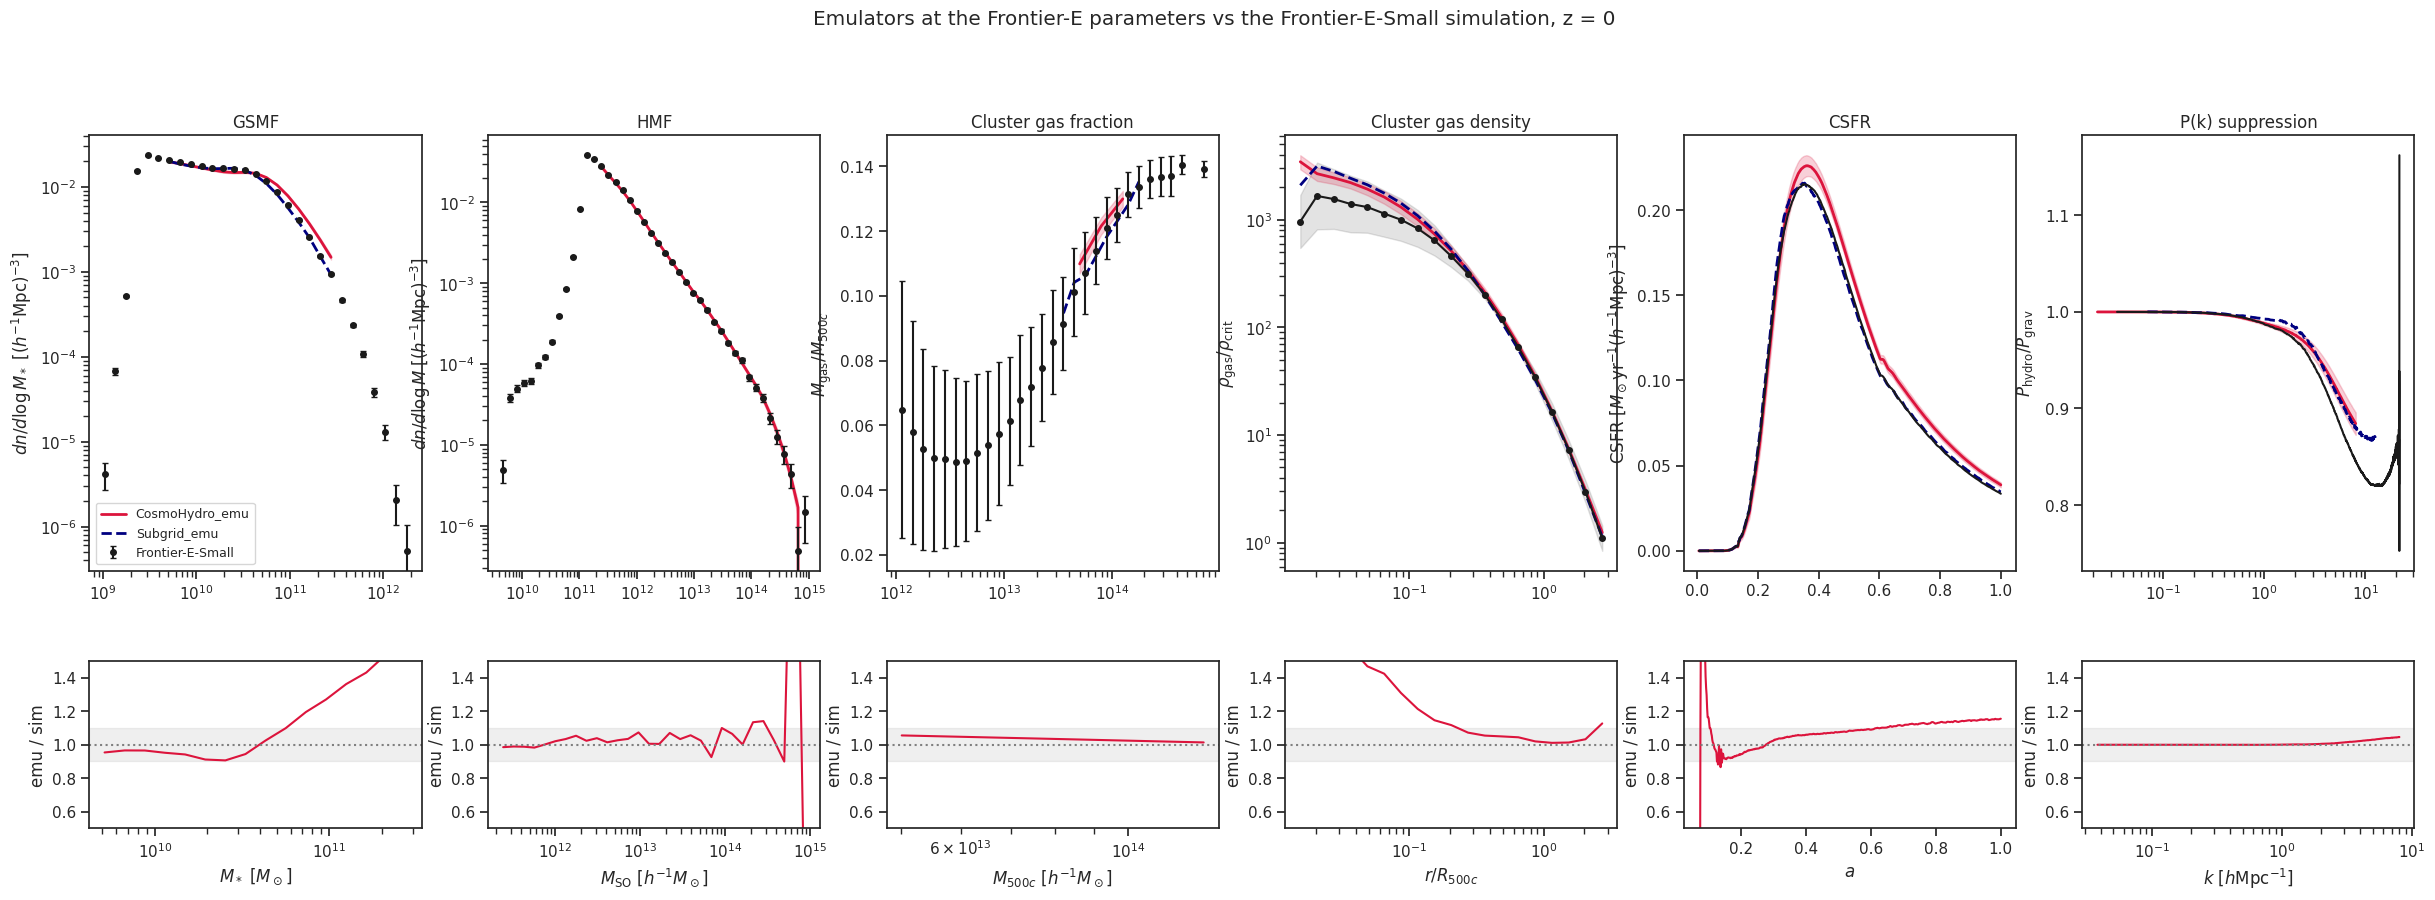

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(30, 9),
                         gridspec_kw={'height_ratios': [2.6, 1], 'hspace': 0.3})

def plot_pair(j, ch_name, sim_x, sim_y, sim_err=None, sg_name=None, title=None,
              xscale='log', yscale='log', xlabel='', ylabel='', sim_bounds=None):
    ax, axr = axes[0, j], axes[1, j]
    if sim_err is not None:
        ax.errorbar(sim_x, sim_y, yerr=sim_err, fmt='o', ms=4, color='k',
                    capsize=2, label='Frontier-E-Small', zorder=5)
    elif sim_bounds is not None:
        ax.plot(sim_x, sim_y, 'o-', ms=4, color='k', label='Frontier-E-Small', zorder=5)
        ax.fill_between(sim_x, sim_bounds[0], sim_bounds[1], color='k', alpha=0.12)
    else:
        ax.plot(sim_x, sim_y, '-', color='k', lw=1.5, label='Frontier-E-Small', zorder=5)

    ch_emu = ce.load_emulator(ch_name)
    p_in = P_COSMO if ch_name == 'Pk_GO' else P7
    ch_mean, ch_std = ch_emu.predict(p_in, z=0.0)
    ch_x, _ = ce.get_x_grid(ch_name)
    ch_x = np.asarray(ch_x)
    ax.plot(ch_x, ch_mean, color='crimson', lw=2, label='CosmoHydro_emu')
    ax.fill_between(ch_x, ch_mean - 2*ch_std, ch_mean + 2*ch_std, color='crimson', alpha=0.2)

    if sg_name is not None:
        sg_mean, sg_std = sge.load_emulator(sg_name).predict(P5)
        sg_x, _ = sge.get_x_grid(sg_name)
        ax.plot(sg_x, sg_mean, color='navy', lw=2, ls='--', label='Subgrid_emu')

    ax.set_xscale(xscale); ax.set_yscale(yscale)
    ax.set_title(title); ax.set_ylabel(ylabel)
    if j == 0:
        ax.legend(fontsize=9)

    # ratio emulator/sim on overlap
    lo, hi = max(ch_x.min(), np.min(sim_x)), min(ch_x.max(), np.max(sim_x))
    mm = (ch_x >= lo) & (ch_x <= hi)
    if xscale == 'log':
        sim_i = np.interp(np.log10(ch_x[mm]), np.log10(sim_x), sim_y)
    else:
        sim_i = np.interp(ch_x[mm], sim_x, sim_y)
    axr.plot(ch_x[mm], ch_mean[mm] / sim_i, color='crimson', lw=1.5)
    axr.axhline(1, color='gray', ls=':')
    axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_xscale(xscale); axr.set_ylim(0.5, 1.5)
    axr.set_xlabel(xlabel); axr.set_ylabel('emu / sim')

x, y, e = read_gsmf(624)
plot_pair(0, 'GSMF', x, y, sim_err=e, sg_name='GSMF', title='GSMF',
          xlabel=r'$M_*$ [$M_\odot$]', ylabel=r'$dn/d\log M_*$ [$(h^{-1}$Mpc$)^{-3}$]')

x, y, e = read_hmf(624)
plot_pair(1, 'HMF', x, y, sim_err=e, title='HMF',
          xlabel=r'$M_{\rm SO}$ [$h^{-1}M_\odot$]', ylabel=r'$dn/d\log M$ [$(h^{-1}$Mpc$)^{-3}$]')

x, y, e = read_fgas(624)
plot_pair(2, 'fGas', x, y, sim_err=e, sg_name='fGas', title='Cluster gas fraction',
          yscale='linear', xlabel=r'$M_{500c}$ [$h^{-1}M_\odot$]', ylabel=r'$M_{\rm gas}/M_{500c}$')

r, y, lo_b, hi_b = read_cgd(624)
plot_pair(3, 'CGD', r, y, sim_bounds=(lo_b, hi_b), sg_name='CGD', title='Cluster gas density',
          xlabel=r'$r/R_{500c}$', ylabel=r'$\rho_{\rm gas}/\rho_{\rm crit}$')

a, y = read_csfr()
plot_pair(4, 'CSFR', a, y, sg_name='CSFR', title='CSFR', xscale='linear', yscale='linear',
          xlabel=r'$a$', ylabel=r'CSFR [$M_\odot$yr$^{-1}(h^{-1}$Mpc$)^{-3}$]')

kk, rr = pk_ratio_sim(624)
plot_pair(5, 'Pk-ratio', kk, rr, sg_name='Pk', title='P(k) suppression', yscale='linear',
          xlabel=r'$k$ [$h$Mpc$^{-1}$]', ylabel=r'$P_{\rm hydro}/P_{\rm grav}$')

plt.suptitle('Emulators at the Frontier-E parameters vs the Frontier-E-Small simulation, z = 0', y=1.02)
plt.tight_layout(); plt.show()

## Redshift evolution: GSMF and HMF (CosmoHydro only — Subgrid_emu is z = 0)

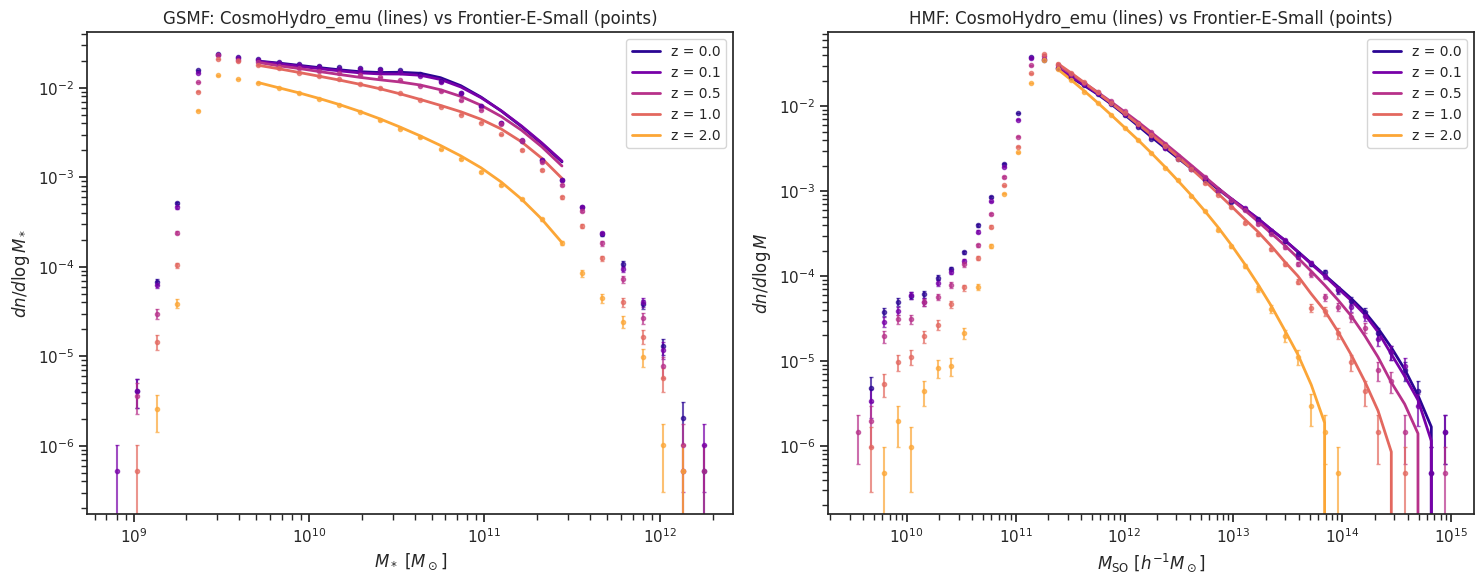

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
zcolors = plt.cm.plasma(np.linspace(0.05, 0.8, len(STEP_Z)))

for ax, (stat, reader) in zip(axes, [('GSMF', read_gsmf), ('HMF', read_hmf)]):
    emu = ce.load_emulator(stat)
    ch_x, _ = ce.get_x_grid(stat)
    for (step, z), c in zip(STEP_Z.items(), zcolors):
        x, y, e = reader(step)
        ax.errorbar(x, y, yerr=e, fmt='o', ms=3, color=c, alpha=0.7, capsize=1.5)
        zi = min(z, 2.0)
        mean, _ = emu.predict(P7, z=zi)
        ax.plot(ch_x, mean, color=c, lw=2, label=f'z = {z}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'{stat}: CosmoHydro_emu (lines) vs Frontier-E-Small (points)')
    ax.legend(fontsize=10)
axes[0].set_xlabel(r'$M_*$ [$M_\odot$]'); axes[0].set_ylabel(r'$dn/d\log M_*$')
axes[1].set_xlabel(r'$M_{\rm SO}$ [$h^{-1}M_\odot$]'); axes[1].set_ylabel(r'$dn/d\log M$')
plt.tight_layout(); plt.show()

## Power spectra: all three emulators vs the **survey-scale** Frontier-E

- **Gravity-only:** CosmoHydro `Pk_GO` and **MiraTitan-IV** vs the 3150 h⁻¹Mpc
  gravity-only companion run.
- **Full hydro:** CosmoHydro `Pk-ratio × Pk_GO` vs the hydro run.

With ~490× the CosmoHydro training volume, sample variance is negligible on all plotted
scales — this is the cleanest emulator test available. The z ≈ 0.25 and 1.5 steps fall
*between* the Pk emulator training snapshots (z = 0, 0.1, 0.5, 1, 2), so those two
panels additionally test the linear-in-z model interpolation.

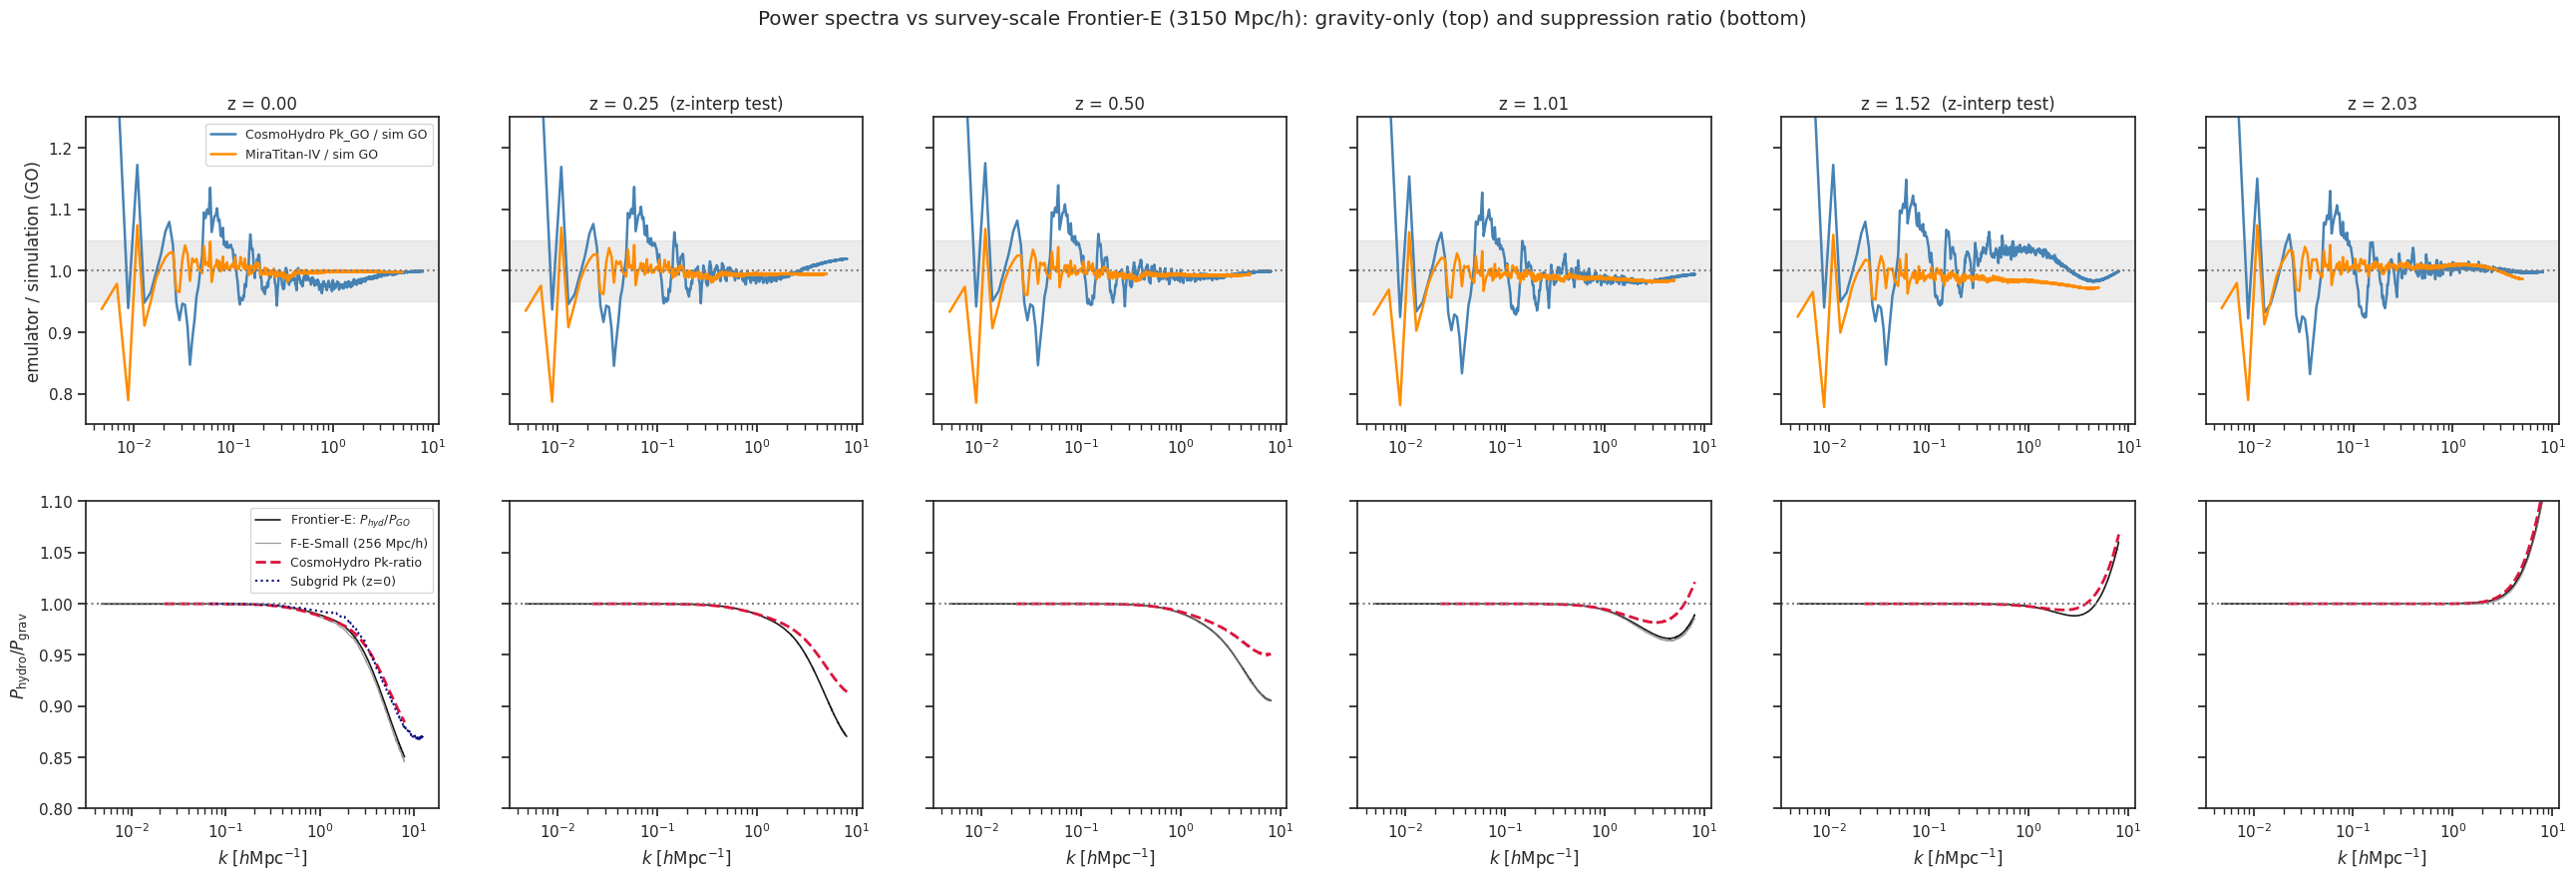

In [6]:
Ob = FP['Omega_b_h2'] / h**2
cosmo = pyccl.Cosmology(Omega_c=FP['Omega_m'] - Ob, Omega_b=Ob, h=h,
                        sigma8=FP['sigma_8'], n_s=FP['n_s'], transfer_function='bbks')
mt_pk2d = CosmicemuMTIVPk('tot').get_pk2d(cosmo)

emu_go = ce.load_emulator('Pk_GO')
emu_ratio = ce.load_emulator('Pk-ratio')
k_ch, _ = ce.get_x_grid('Pk_GO')
k_ch = np.asarray(k_ch)

fig, axes = plt.subplots(2, len(FE_STEPS), figsize=(32, 9), sharey='row',
                         gridspec_kw={'hspace': 0.25})

for j, step in enumerate(FE_STEPS):
    z = step_to_z(step)
    z = min(z, 2.0)   # step 205 is z = 2.03; clamp to the emulator z-range edge
    ax, axb = axes[0, j], axes[1, j]
    kg, pg, _ = read_pk_fe(step, go=True)
    ksel = (kg > 0.004) & (kg < 8)
    kg, pg = kg[ksel], pg[ksel]

    pgo_emu, _ = emu_go.predict(P_COSMO, z=z)
    pgo_i = np.interp(np.log10(kg), np.log10(k_ch), pgo_emu)
    pmt = mt_pk2d(kg * h, 1/(1+z), cosmo) * h**3

    ax.semilogx(kg, pgo_i / pg, color='steelblue', lw=1.8, label='CosmoHydro Pk_GO / sim GO')
    mmt = kg <= 5.0
    ax.semilogx(kg[mmt], (pmt / pg)[mmt], color='darkorange', lw=1.8, label='MiraTitan-IV / sim GO')
    ax.axhline(1, color='gray', ls=':'); ax.axhspan(0.95, 1.05, color='gray', alpha=0.15)
    interp_note = '  (z-interp test)' if step in (498, 247) else ''
    ax.set_ylim(0.75, 1.25); ax.set_title(f'z = {step_to_z(step):.2f}{interp_note}')
    if j == 0:
        ax.set_ylabel('emulator / simulation (GO)'); ax.legend(fontsize=9)

    # hydro suppression
    ks, rs = pk_ratio_fe(step)
    msel = (ks > 0.004) & (ks < 8)
    r_emu, _ = emu_ratio.predict(P7, z=z)
    axb.semilogx(ks[msel], rs[msel], color='k', lw=1.2, label='Frontier-E: $P_{hyd}/P_{GO}$')
    ks_s, rs_s = pk_ratio_sim(step) if step in STEP_Z else (None, None)
    if ks_s is not None:
        ms_s = (ks_s > 0.03) & (ks_s < 8)
        axb.semilogx(ks_s[ms_s], rs_s[ms_s], color='gray', lw=0.9, alpha=0.8,
                     label='F-E-Small (256 Mpc/h)')
    axb.semilogx(k_ch, r_emu, color='crimson', lw=2, ls='--', label='CosmoHydro Pk-ratio')
    if step == 624:
        sg_mean, _ = sge.load_emulator('Pk').predict(P5)
        sg_k, _ = sge.get_x_grid('Pk')
        axb.semilogx(sg_k, sg_mean, color='navy', lw=1.5, ls=':', label='Subgrid Pk (z=0)')
    axb.axhline(1, color='gray', ls=':')
    axb.set_ylim(0.8, 1.1)
    axb.set_xlabel(r'$k$ [$h$Mpc$^{-1}$]')
    if j == 0:
        axb.set_ylabel(r'$P_{\rm hydro}/P_{\rm grav}$'); axb.legend(fontsize=9)

plt.suptitle('Power spectra vs survey-scale Frontier-E (3150 Mpc/h): gravity-only (top) and suppression ratio (bottom)', y=1.0)
plt.tight_layout(); plt.show()

## Survey-scale Frontier-E catalogs (OpenCosmo portal)

Halo/galaxy catalog queries at z = 0 (halos with M₂₀₀c above 10¹³ and galaxies with
M\* > 10¹¹ M☉) belong in `../data_sims/frontier_e/catalogs/`. From these we recompute
the HMF, the massive end of the GSMF, and fGas(M₅₀₀c) in the full 3150 h⁻¹Mpc volume.
**These cells skip gracefully while the files are absent** (the portal's compute
endpoint `hacc-compute-portal-polaris-1-node` was offline at the last refresh;
only the power spectra above have been transferred so far).

In [7]:
import glob
FE_CAT_DIR = '../data_sims/frontier_e/catalogs'
fe_files = sorted(f for f in glob.glob(f'{FE_CAT_DIR}/*') if os.path.isfile(f))
if fe_files:
    for f in fe_files:
        print(f, f'{os.path.getsize(f)/1e6:.1f} MB')
else:
    print('No survey-scale Frontier-E catalogs found under', FE_CAT_DIR)
    print('(re-run the OpenCosmo halo/galaxy catalog queries when the endpoint is back')
    print(' and drop the result files there, then re-execute this section)')

No survey-scale Frontier-E catalogs found under ../data_sims/frontier_e/catalogs
(re-run the OpenCosmo halo/galaxy catalog queries when the endpoint is back
 and drop the result files there, then re-execute this section)


In [8]:
VOL_FE = 3150.0**3   # (Mpc/h)^3

def load_catalog(path):
    """Load a portal catalog file (parquet or hdf5) into a dict of columns."""
    if path.endswith(('.parquet', '.pq')):
        import pandas as pd
        return pd.read_parquet(path)
    if path.endswith(('.h5', '.hdf5')):
        import h5py
        f = h5py.File(path, 'r')
        return f
    raise ValueError(f'unrecognized catalog format: {path}')

halo_file = next((f for f in fe_files if 'halo' in os.path.basename(f).lower()), None)
gal_file = next((f for f in fe_files if 'gal' in os.path.basename(f).lower()), None)
print('halo catalog:', halo_file)
print('galaxy catalog:', gal_file)

halo catalog: None
galaxy catalog: None


In [9]:
if halo_file:
    cat = load_catalog(halo_file)
    print(list(cat.keys()) if not hasattr(cat, 'columns') else list(cat.columns))
else:
    print('skipped (no halo catalog)')

skipped (no halo catalog)


In [10]:
def mass_function(masses, vol, bins):
    """dn/dlog10M in vol^-1 units."""
    hist, edges = np.histogram(np.log10(masses), bins=bins)
    dlog = np.diff(edges)
    ctr = 10**(0.5 * (edges[1:] + edges[:-1]))
    phi = hist / vol / dlog
    err = np.sqrt(hist) / vol / dlog
    return ctr, phi, err, hist

if halo_file:
    df = load_catalog(halo_file)
    mcol = 'sod_halo_mass' if 'sod_halo_mass' in df else df.columns[0]
    ctr, phi, err, cnt = mass_function(np.asarray(df[mcol]), VOL_FE,
                                       np.arange(13.0, 15.6, 0.15))
    hm_emu = ce.load_emulator('HMF')
    hm_mean, hm_std = hm_emu.predict(P7, z=0.0)
    hm_x, _ = ce.get_x_grid('HMF')

    fig, ax = plt.subplots(figsize=(8, 6))
    good = cnt > 0
    ax.errorbar(ctr[good], phi[good], yerr=err[good], fmt='o', ms=4, color='k',
                capsize=2, label='Frontier-E (survey volume)')
    ax.plot(hm_x, hm_mean, color='crimson', lw=2, label='CosmoHydro_emu HMF')
    ax.fill_between(hm_x, hm_mean - 2*hm_std, hm_mean + 2*hm_std, color='crimson', alpha=0.2)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('halo mass'); ax.set_ylabel(r'$dn/d\log M$')
    ax.set_title('Survey-scale Frontier-E HMF vs CosmoHydro_emu, z = 0')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('skipped (no halo catalog)')

skipped (no halo catalog)


## Notes

- **Frontier-E-Small** shares the calibrated subgrid parameters and resolution of the
  survey-scale run, and its HAVOCC extracts use the same measurement definitions as the
  emulator training data — this makes it the cleanest emulator test. Its 256 h⁻¹Mpc volume,
  however, is *smaller* than the CosmoHydro training boxes (400 h⁻¹Mpc): cluster statistics
  (fGas, CGD, high-mass HMF/GSMF) carry visible sample variance, and P(k) at k ≲ 0.1 h Mpc⁻¹
  is dominated by a handful of modes.
- The Frontier-E-Small parameters sit near (but not exactly at) points probed by the
  training designs of both suites — this is an interpolation test, not a training-point
  lookup.
- **MiraTitan-IV** enters through the gravity-only spectra: agreement with the survey-scale
  GO companion at the few-percent level for 0.01 ≲ k ≲ 5 h Mpc⁻¹ ties all three emulators
  to the same simulation campaign, now with negligible sample variance.
- The z ≈ 0.25 and z ≈ 1.5 spectra test the emulators **between** training snapshots
  (linear model interpolation in z).
- The **catalog section** will remove the small-volume caveat for HMF/GSMF/fGas; refresh it
  once the OpenCosmo portal endpoint is back online.